In [38]:
import pandas as pd
import folium
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# File path
file_path = '20250311_firstBox.txt'

# Read the data into a DataFrame
df = pd.read_csv(file_path)

# Convert 'time' column to datetime format
df['time'] = pd.to_datetime(df['time'], format='%y-%m-%d %H:%M:%S')

# Set 'time' column as the index
df.set_index('time', inplace=True)

# Localize the naive datetime to UTC first
df.index = df.index.tz_localize('UTC').tz_convert('America/Los_Angeles')

# Ensure that longitude values are negative
df['lon'] = -df['lon']

df.tail()
# print(df['lat'].tail())s
# print(df['lon'].tail())

# Function to convert DD.MMmm to decimal degrees
# From ChatGPT
def convert_to_decimal_degrees(coord):
    degrees = int(coord)  # Extract degrees (integer part)
    minutes = abs(coord - degrees) * 100  # Extract the minutes
    decimal_degrees = abs(degrees) + minutes / 60  # Convert minutes to decimal and add to degrees
    return decimal_degrees if coord >= 0 else -decimal_degrees  # Keep the sign for negative coordinates

# Apply the conversion function to the lat and lon columns
df['lat_decimal'] = df['lat'].apply(convert_to_decimal_degrees)
df['lon_decimal'] = df['lon'].apply(convert_to_decimal_degrees)

print(df[['lat_decimal', 'lon_decimal']])

                           lat_decimal  lon_decimal
time                                               
2025-03-12 00:06:33-07:00    37.973333  -122.535833
2025-03-12 00:06:44-07:00    37.973333  -122.535833
2025-03-12 00:06:55-07:00    37.973333  -122.535833
2025-03-12 00:07:06-07:00    37.973333  -122.535833
2025-03-12 00:07:17-07:00    37.973333  -122.535833
...                                ...          ...
2025-03-12 13:31:31-07:00    37.968000  -122.530667
2025-03-12 13:31:42-07:00    37.968000  -122.530667
2025-03-12 13:31:53-07:00    37.968000  -122.530667
2025-03-12 13:32:04-07:00    37.968000  -122.530667
2025-03-12 13:32:15-07:00    37.968000  -122.530667

[4336 rows x 2 columns]


In [28]:
# Create a Folium map centered at the first location
m = folium.Map(location=[df.iloc[0]['lat_decimal'], df.iloc[0]['lon_decimal']], zoom_start=16)

# Prepare the coordinates for the polyline
coordinates = df[['lat_decimal', 'lon_decimal']].values.tolist()

# Add a line connecting the points
folium.PolyLine(coordinates, color='blue', weight=2.5, opacity=1).add_to(m)

# Save map to an HTML file
m.save('20250311_firstBox.html')


In [6]:
df.keys()

Index(['tempC', 'tempF', 'humidity', 'pressurehPa', 'fix', 'fixQual', 'lat',
       'latDir', 'lon', 'lonDir', 'speed', 'angle', 'alt', 'satNum',
       'lat_decimal', 'lon_decimal'],
      dtype='object')

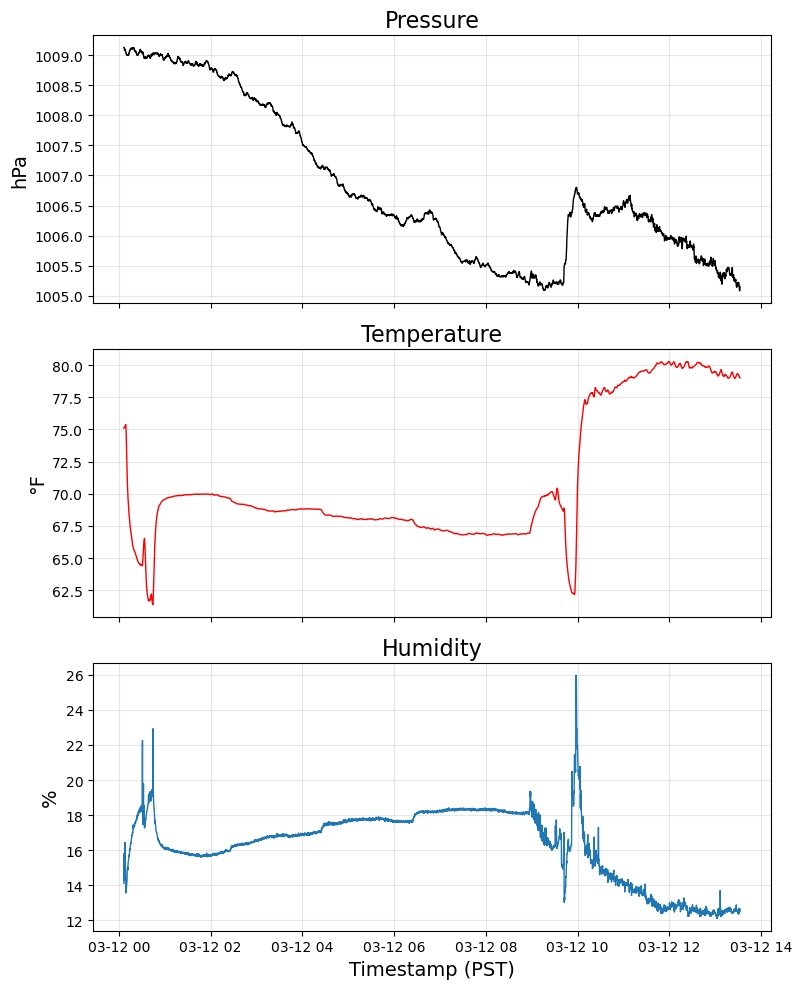

In [91]:
import matplotlib.dates as mdates

plt.figure(figsize=(8, 10))

plt.subplot(3, 1, 1)
plt.plot(df.index, df['pressurehPa'],color='black',linewidth=1)
plt.title('Pressure', fontsize=16)
plt.ylabel('hPa', fontsize=14)
plt.grid(True, alpha=0.3)
plt.gca().set_xticklabels([])  # Remove x-tick labels for the first plot

plt.subplot(3, 1, 2)
plt.plot(df.index, df['tempF'],color='red',linewidth=1)
plt.title('Temperature', fontsize=16)
plt.ylabel('°F', fontsize=14)
plt.grid(True, alpha=0.3)
plt.gca().set_xticklabels([])  # Remove x-tick labels for the second plot

plt.subplot(3, 1, 3)
plt.plot(df.index, df['humidity'],linewidth=1)
plt.title('Humidity', fontsize=16)
plt.ylabel('%', fontsize=14)
plt.xlabel('Timestamp (PST)', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
